# Split Classification Training Data

In this notebook, original data will be splitted in Train, Validation and Test datasets. The data will be splitted in a stratified way, so the distribution of the target variable will be the same in all datasets.

- Train: Will be used to train the model and learn parameters.
- Validation: Will be used to tune the model hyperparameters and make decisions about the model.
- Test: Will be used to evaluate the model performance and perform some error analysis.

Split indices are saved in a json called `splits.json`.

In [1]:
import pandas as pd

df = pd.read_csv("nbs/other/claim_matching_dataset.csv")
print("Number of rows: ", len(df))
print(f"Columns ({len(df.columns)}): ", df.columns)
df.head()

Number of rows:  3868
Columns (23):  Index(['Unnamed: 0.1', 'Unnamed: 0', 'unverified claim', 'reviewed claim',
       'similarity', 'url', 'title', 'text', 'summary', 'meta_description',
       'kb_keywords', 'meta_keywords', 'cr_country', 'meta_lang', 'cr_image',
       'meta_image', 'movies', 'domain', 'cm_authors', 'cr_author_name',
       'cr_author_url', 'cr_item_reviewed_text', 'dataset'],
      dtype='object')


,Unnamed: 0.1,Unnamed: 0,unverified claim,reviewed claim,similarity,url,title,text,summary,meta_description,...,meta_lang,cr_image,meta_image,movies,domain,cm_authors,cr_author_name,cr_author_url,cr_item_reviewed_text,dataset
0,25,26,El dióxido de cloro ayuda a sanar la esclerósi...,Dióxido de cloro ayuda a sanar esclerosis múlt...,1,https://factual.afp.com/doc.afp.com.32GA6AY,El dióxido de cloro no “ayuda a sanar” la escl...,El dióxido de cloro no “ayuda a sanar” la escl...,El dióxido de cloro no tiene propiedades aprob...,El dióxido de cloro no tiene propiedades aprob...,...,es,https://factual.afp.com/sites/default/files/st...,https://factual.afp.com/sites/default/files/st...,[],factual.afp.com,[],AFP Factual,factual.afp.com,Dióxido de cloro ayuda a sanar esclerosis múlt...,train
1,26,27,El dióxido de cloro ayuda a sanar la esclerósi...,El dióxido de cloro tiene propiedades curativas,1,https://www.europapress.es/verificaciones/noti...,Cuidado con los mensajes que recomiendan las i...,Archivo - Investigador probando muestras en un...,Se ha difundido un mensaje en redes sociales s...,Está circulando en redes sociales un mensaje q...,...,es,https://img.europapress.es/fotoweb/fotonoticia...,https://img.europapress.es/fotoweb/fotonoticia...,[],www.europapress.es,"['Europa Press Verificaciones', 'Europa Press']",Europa Press,europapress.es,El dióxido de cloro tiene propiedades curativas,train
2,37,38,Pilotos de aviación se manifiestan en un aerop...,Centenas de pilotos de avião protestam contra ...,1,https://poligrafo.sapo.pt/fact-check/video-mos...,Vídeo mostra centenas de pilotos de avião a pr...,"""Última hora! Greve de mais de 400 pilotos do ...",Uma greve de mais de 400 pilotos no aeroporto ...,"Do TikTok para o Instagram e Facebook, o vídeo...",...,pt,https://thumbs.web.sapo.io/?W=1200&H=630&delay...,https://thumbs.web.sapo.io/?W=1200&H=630&delay...,[],poligrafo.sapo.pt,"['Polígrafo', 'Gustavo Sampaio']",Polígrafo - SAPO,poligrafo.sapo.pt,Centenas de pilotos de avião protestam contra ...,train
3,38,39,Pilotos de aviación se manifiestan en un aerop...,Delta Pilots In Video Were Protesting COVID-19...,1,https://leadstories.com/hoax-alert/2022/07/fac...,Fact Check: Delta Pilots In Video Were NOT Pro...,Protesting Pay\n\nDoes this video show Delta A...,The video circulating on TikTok showing Delta ...,Does this video show Delta Air Lines pilots pr...,...,en,https://leadstories.com/caption_3479196.jpg,https://leadstories.com/caption_3479196.jpg,[],leadstories.com,"['Lead Stories Staff', 'Lead Stories LLC']",Lead Stories,leadstories.com,Delta Pilots In Video Were Protesting COVID-19...,train
4,39,40,Pilotos de aviación se manifiestan en un aerop...,Des pilotes de Delta Airlines manifestent cont...,1,https://factuel.afp.com/doc.afp.com.32DY8NY,"Non, ces pilotes de Delta Airlines ne manifest...","Non, ces pilotes de Delta Airlines ne manifest...",Des vidéos sur Twitter prétendant montrer des ...,Une vidéo visionnée des milliers de fois sur T...,...,fr,https://factuel.afp.com/sites/default/files/st...,https://factuel.afp.com/sites/default/files/st...,[],factuel.afp.com,[],AFP Factuel,factuel.afp.com,Des pilotes de Delta Airlines manifestent cont...,train


In [12]:
df_claims = df["unverified claim"].reset_index()
df_claims.columns = ["claim_id", "unverified claim"]
df_claims = df_claims.dropna()
df_claims = df_claims.drop_duplicates(subset="unverified claim")
df_claims

,claim_id,unverified claim
0,0,El dióxido de cloro ayuda a sanar la esclerósi...
2,2,Pilotos de aviación se manifiestan en un aerop...
7,7,aviones de guerra americanos han escoltado a N...
11,11,La CNN ha dicho que la guerra de Ucrania está ...
12,12,El padre del fundador del World Economic Forum...
...,...,...
3795,3795,video feijoo borracho
3811,3811,más de 100 países rechazaron en la ONU una res...
3828,3828,la agenda 2030 quiere destruir la soberania de...
3845,3845,Anses va a pagar a colectivo LGBTIQ+ por su or...


In [13]:
df_total = pd.merge(df_claims, df, on="unverified claim")

In [ ]:
df_total["claim_id"].isnull().sum()


0

In [16]:
from sklearn.model_selection import train_test_split
# df_total = df_total.set_index("claim_id")

train_idx, test_idx = train_test_split(df_total.claim_id.unique(), test_size=0.1, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=42)


print("Train size (different ids): ", len(train_idx))
print("Val size (different ids): ", len(val_idx))
print("Test size (different ids): ", len(test_idx))

train_idx = df_total[df_total.claim_id.isin(train_idx)].index
val_idx = df_total[df_total.claim_id.isin(val_idx)].index
test_idx = df_total[df_total.claim_id.isin(test_idx)].index

print("Train size: ", len(train_idx))
print("Val size: ", len(val_idx))
print("Test size: ", len(test_idx))

Train size (different ids):  191
Val size (different ids):  22
Test size (different ids):  24
Train size:  3119
Val size:  356
Test size:  390


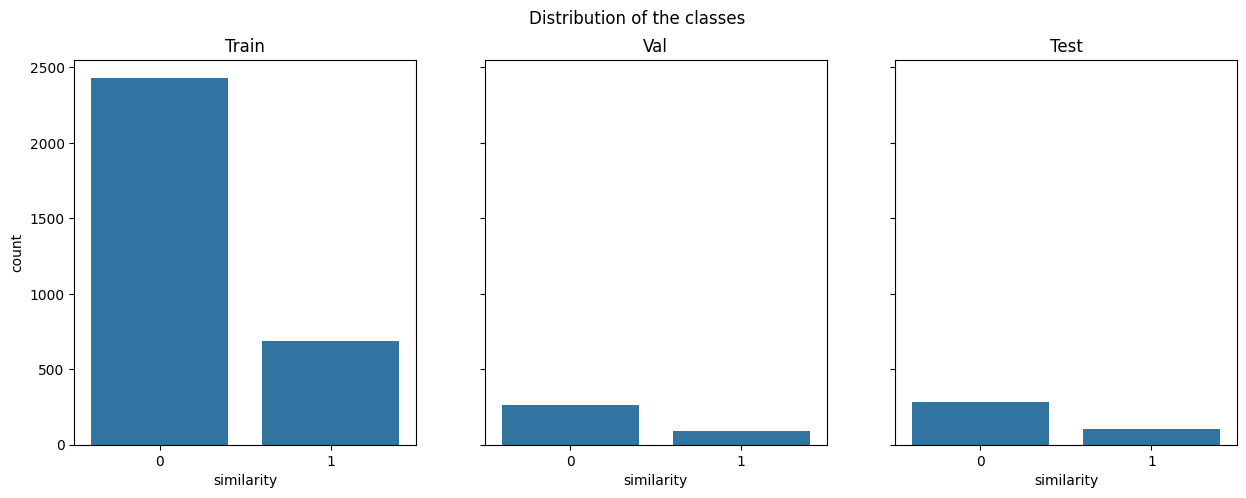

In [17]:
df_train = df.loc[train_idx]
df_val = df.loc[val_idx]
df_test = df.loc[test_idx]

# Plot the distribution of the classes using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
sns.countplot(data=df_train, x="similarity", ax=ax[0])
ax[0].set_title("Train")
sns.countplot(data=df_val, x="similarity", ax=ax[1])
ax[1].set_title("Val")
sns.countplot(data=df_test, x="similarity", ax=ax[2])
ax[2].set_title("Test")

plt.suptitle("Distribution of the classes")
plt.show()


In [18]:
d_splits = {
    "train": train_idx.tolist(),
    "val": val_idx.tolist(),
    "test": test_idx.tolist()
}

import json
json.dump(d_splits, open("nbs/other/splits.json", "w"), indent=2)